#### A class that performs Economic Assessment with uncertainty. There are two methods within the class, assess and Graph. The asses method calculates the net present value (NPV-default). The are also the option of calculating the payback and the net payback periods (which can be specified when calling the assess method). The implementation assumes the cash flows follow either a uniform (default) or a Gaussian distribution. The default number of iterations and rate of return are 1m and 10%, respectively. Users can set their preferred number of parameters when creating the class object

In [1]:
import numpy as np
import pandas as pd
class EconomicAssessment:
  def __init__(self, data:dict,initial_cost=None,iterations=10000)->np.array:
    self.data = data
    self.iterations=iterations
    self.initial_cost = int(input('Input the intial Cost: '))
  def Assess(self, distribution='uniform', r=10, kind='NCF',
          expected_inflation=None):#Monte Carlo simulation
    if type(self.data)=='dict': df = pd.read_csv(self.data)
    else:df=pd.DataFrame(self.data)
    a=[]
    if distribution=='gaussian':
      for i in range(self.iterations):
        df_rand=df.copy()
        df_rand['inflow_rand']=np.random.normal(df_rand['inflow'].mean(),df_rand['inflow'].std(), size=len(df_rand))
        df_rand['outflow_rand']=np.random.normal(df_rand['outflow'].mean(),df_rand['outflow'].std(), size=len(df_rand))
        if kind=='Payback':
          pass
        elif kind=='Net_payback':
          pass
        else:
          df_rand['ncf']=(df_rand['inflow_rand']-df_rand['outflow_rand'])/((1+r/100)**df_rand['period'])
          net = df_rand['ncf'].sum()-self.initial_cost
          a.append(net)
      return a
    else:
      for i in range(self.iterations):
        df_rand=df.copy()
        df_rand['inflow_rand']=np.random.uniform(df_rand['inflow'].min(),df_rand['inflow'].max(), size=len(df_rand))
        df_rand['outflow_rand']=np.random.uniform(df_rand['outflow'].min(),df_rand['outflow'].max(), size=len(df_rand))
        if kind=='payback':
          df_rand['ncf']=(df_rand['inflow_rand']-df_rand['outflow_rand'])
          i=np.argmin(np.abs(df_rand['ncf'].cumsum()-self.initial_cost))
          i=df_rand['period']
          a.append(df_rand['period'][i])
        elif kind=='net_payback':
          df_rand['ncf']=(df_rand['inflow_rand']-df_rand['outflow_rand'])
          I = df_rand['period'] if (df_rand['ncf'].cumsum()==self.initial_cost).any() else None
        else:
          df_rand['ncf']=(df_rand['inflow_rand']-df_rand['outflow_rand'])/(1+r/100)**df_rand['period']
          net = df_rand['ncf'].sum()-self.initial_cost
          a.append(net)
      return a
  def internal_rate(self):
    data=pd.DataFrame(self.data.copy())
    irr=0.001
    net =-1
    while abs(net) > 1e-3:
      data['ncf']=(data['inflow']-data['outflow'])/((1+irr)**data['period'])
      net = data['ncf'].sum()-self.initial_cost
      if net<0:irr-=0.0001
      else:irr+=0.0001
      #print(net,irr)
      if abs(net)<=0.05: break
    print(net)
    return str(round(irr*100,2))+'%'

  def Graph(self):
    import matplotlib.pyplot as plt
    import seaborn as sns
    sns.kdeplot(self.Assess(), fill=True)
    plt.title('Economic Assessment')
    plt.show()

In [2]:
data={'period':[1,  2,  3,  4,  5], 
      'inflow':[25,30,35, 40, 45],  
      'outflow': [10,11,12,13,14]    
     }

Assess=EconomicAssessment(data)

Input the intial Cost:  65


In [3]:
Assess.internal_rate()

0.03467526992137948


'19.67%'

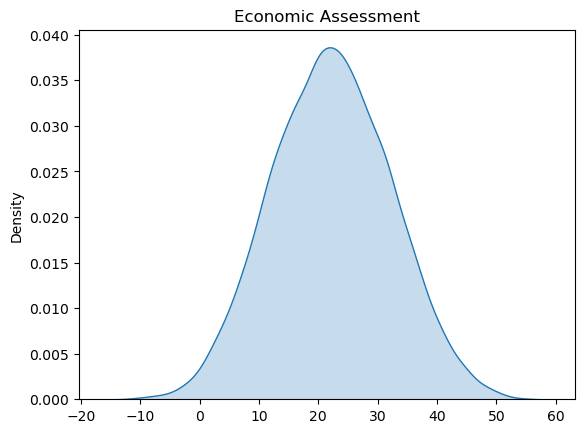

In [4]:
Assess.Graph()